In [ ]:
!pip install keras tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Conv1D, MaxPooling1D, Flatten, Dropout

In [ ]:
df = pd.read_csv('Dataset El Nino & La Nina - FIX.csv')

In [ ]:
df.head()

,weather_code,temperature_2m_max,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,wind_speed_10m_max,label
0,63.0,31.0,24.9,33224.84,20.6,20.6,16.3,la nina
1,65.0,30.2,25.1,22994.60,10.9,10.9,13.0,la nina
2,53.0,30.1,25.5,27612.70,1.7,1.7,8.7,la nina
3,63.0,29.1,25.4,20388.78,6.9,6.9,9.9,la nina
4,63.0,30.4,25.3,35931.55,11.4,11.4,7.4,la nina


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 weather_code           2
temperature_2m_max     2
temperature_2m_mean    4
sunshine_duration      4
precipitation_sum      4
rain_sum               4
wind_speed_10m_max     2
label                  0
dtype: int64


#PreProcessing

###Missing Value

In [ ]:
features = ['temperature_2m_max', 'temperature_2m_mean', 'sunshine_duration',
            'precipitation_sum', 'rain_sum', 'wind_speed_10m_max']

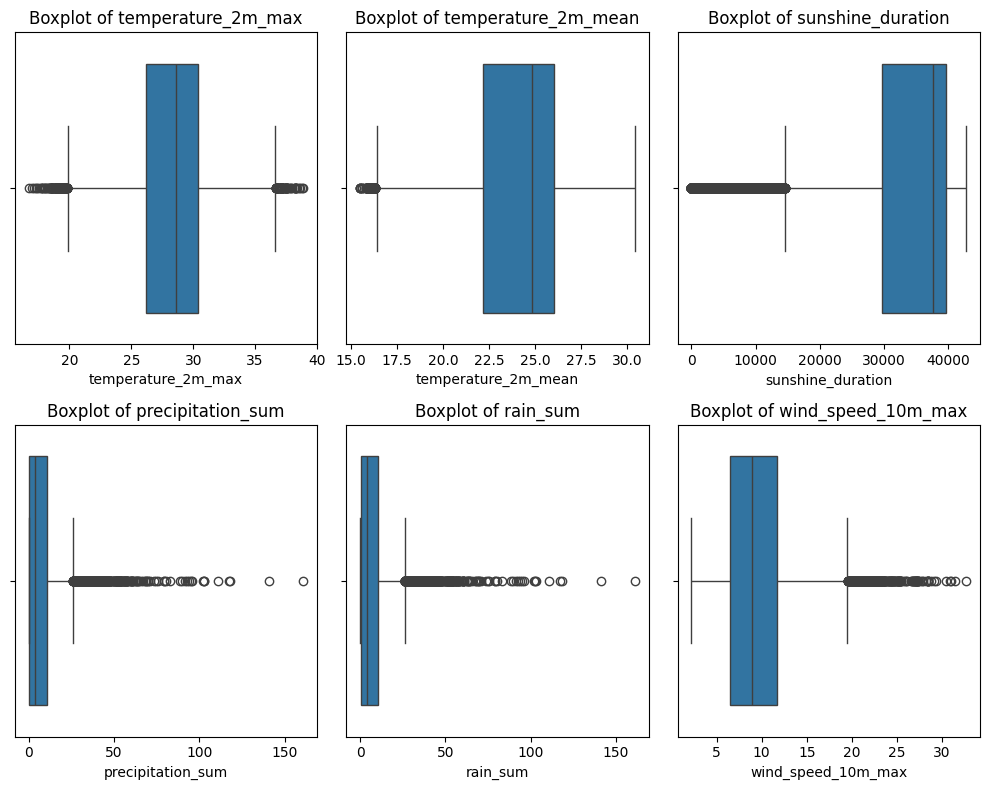

In [ ]:
plt.figure(figsize=(10, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

In [ ]:
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"{feature}: Found {len(outliers)} outliers")

temperature_2m_max: Found 223 outliers
temperature_2m_mean: Found 100 outliers
sunshine_duration: Found 1077 outliers
precipitation_sum: Found 801 outliers
rain_sum: Found 801 outliers
wind_speed_10m_max: Found 388 outliers


In [ ]:
df['label_encoded'] = df['label'].map({'la nina': 0, 'el nino': 1})
df.head()

,weather_code,temperature_2m_max,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,wind_speed_10m_max,label,label_encoded
0,63.0,31.0,24.9,33224.84,20.6,20.6,16.3,la nina,0
1,65.0,30.2,25.1,22994.60,10.9,10.9,13.0,la nina,0
2,53.0,30.1,25.5,27612.70,1.7,1.7,8.7,la nina,0
3,63.0,29.1,25.4,20388.78,6.9,6.9,9.9,la nina,0
4,63.0,30.4,25.3,35931.55,11.4,11.4,7.4,la nina,0


In [ ]:
df.drop('label', axis=1, inplace=True)
df.head()

,weather_code,temperature_2m_max,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,wind_speed_10m_max,label_encoded
0,63.0,31.0,24.9,33224.84,20.6,20.6,16.3,0
1,65.0,30.2,25.1,22994.60,10.9,10.9,13.0,0
2,53.0,30.1,25.5,27612.70,1.7,1.7,8.7,0
3,63.0,29.1,25.4,20388.78,6.9,6.9,9.9,0
4,63.0,30.4,25.3,35931.55,11.4,11.4,7.4,0


In [ ]:
df.fillna(df.median(), inplace=True)

In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 weather_code           0
temperature_2m_max     0
temperature_2m_mean    0
sunshine_duration      0
precipitation_sum      0
rain_sum               0
wind_speed_10m_max     0
label_encoded          0
dtype: int64


In [ ]:
df.head()

,weather_code,temperature_2m_max,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,wind_speed_10m_max,label_encoded
0,63.0,31.0,24.9,33224.84,20.6,20.6,16.3,0
1,65.0,30.2,25.1,22994.60,10.9,10.9,13.0,0
2,53.0,30.1,25.5,27612.70,1.7,1.7,8.7,0
3,63.0,29.1,25.4,20388.78,6.9,6.9,9.9,0
4,63.0,30.4,25.3,35931.55,11.4,11.4,7.4,0


# Split Data

In [ ]:
X = df[features]
y = df['label_encoded']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Normalization

In [ ]:
scaler = MinMaxScaler()
X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

In [ ]:
X_train.head()

,temperature_2m_max,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,wind_speed_10m_max
10010,0.662162,0.731544,0.931230,0.000000,0.000000,0.539249
3698,0.216216,0.100671,0.595439,0.104348,0.104348,0.098976
6897,0.518018,0.456376,0.952670,0.002484,0.002484,0.170648
3451,0.342342,0.174497,0.925472,0.004969,0.004969,0.208191
5034,0.608108,0.597315,0.932610,0.000000,0.000000,0.511945


In [ ]:
X_test.head()

,temperature_2m_max,temperature_2m_mean,sunshine_duration,precipitation_sum,rain_sum,wind_speed_10m_max
20377,0.689189,0.744966,0.873906,0.003106,0.003106,0.607509
369,0.495495,0.624161,0.820456,0.003106,0.003106,0.501706
18933,0.608108,0.697987,0.756787,0.061491,0.061491,0.153584
14040,0.486486,0.536913,0.909150,0.000000,0.000000,0.320819
18627,0.635135,0.758389,0.920707,0.014286,0.014286,0.122867


### Correlation heatmap

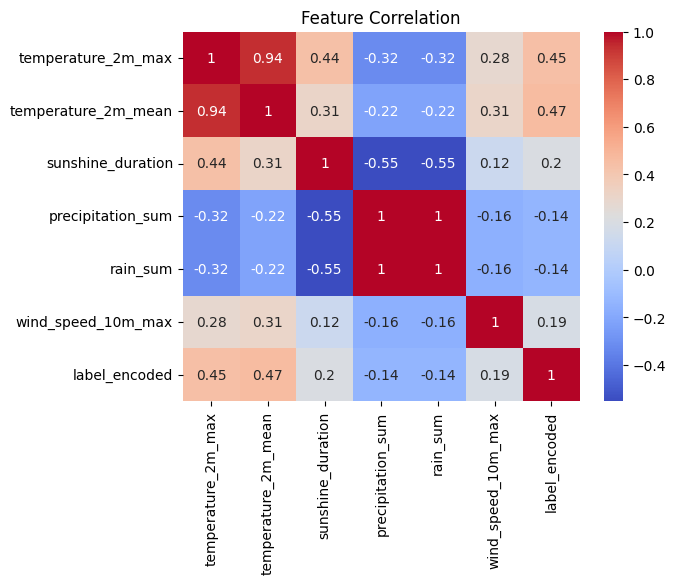

In [ ]:
correlation_matrix = df[features + ['label_encoded']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

### Pairplot for feature interactions

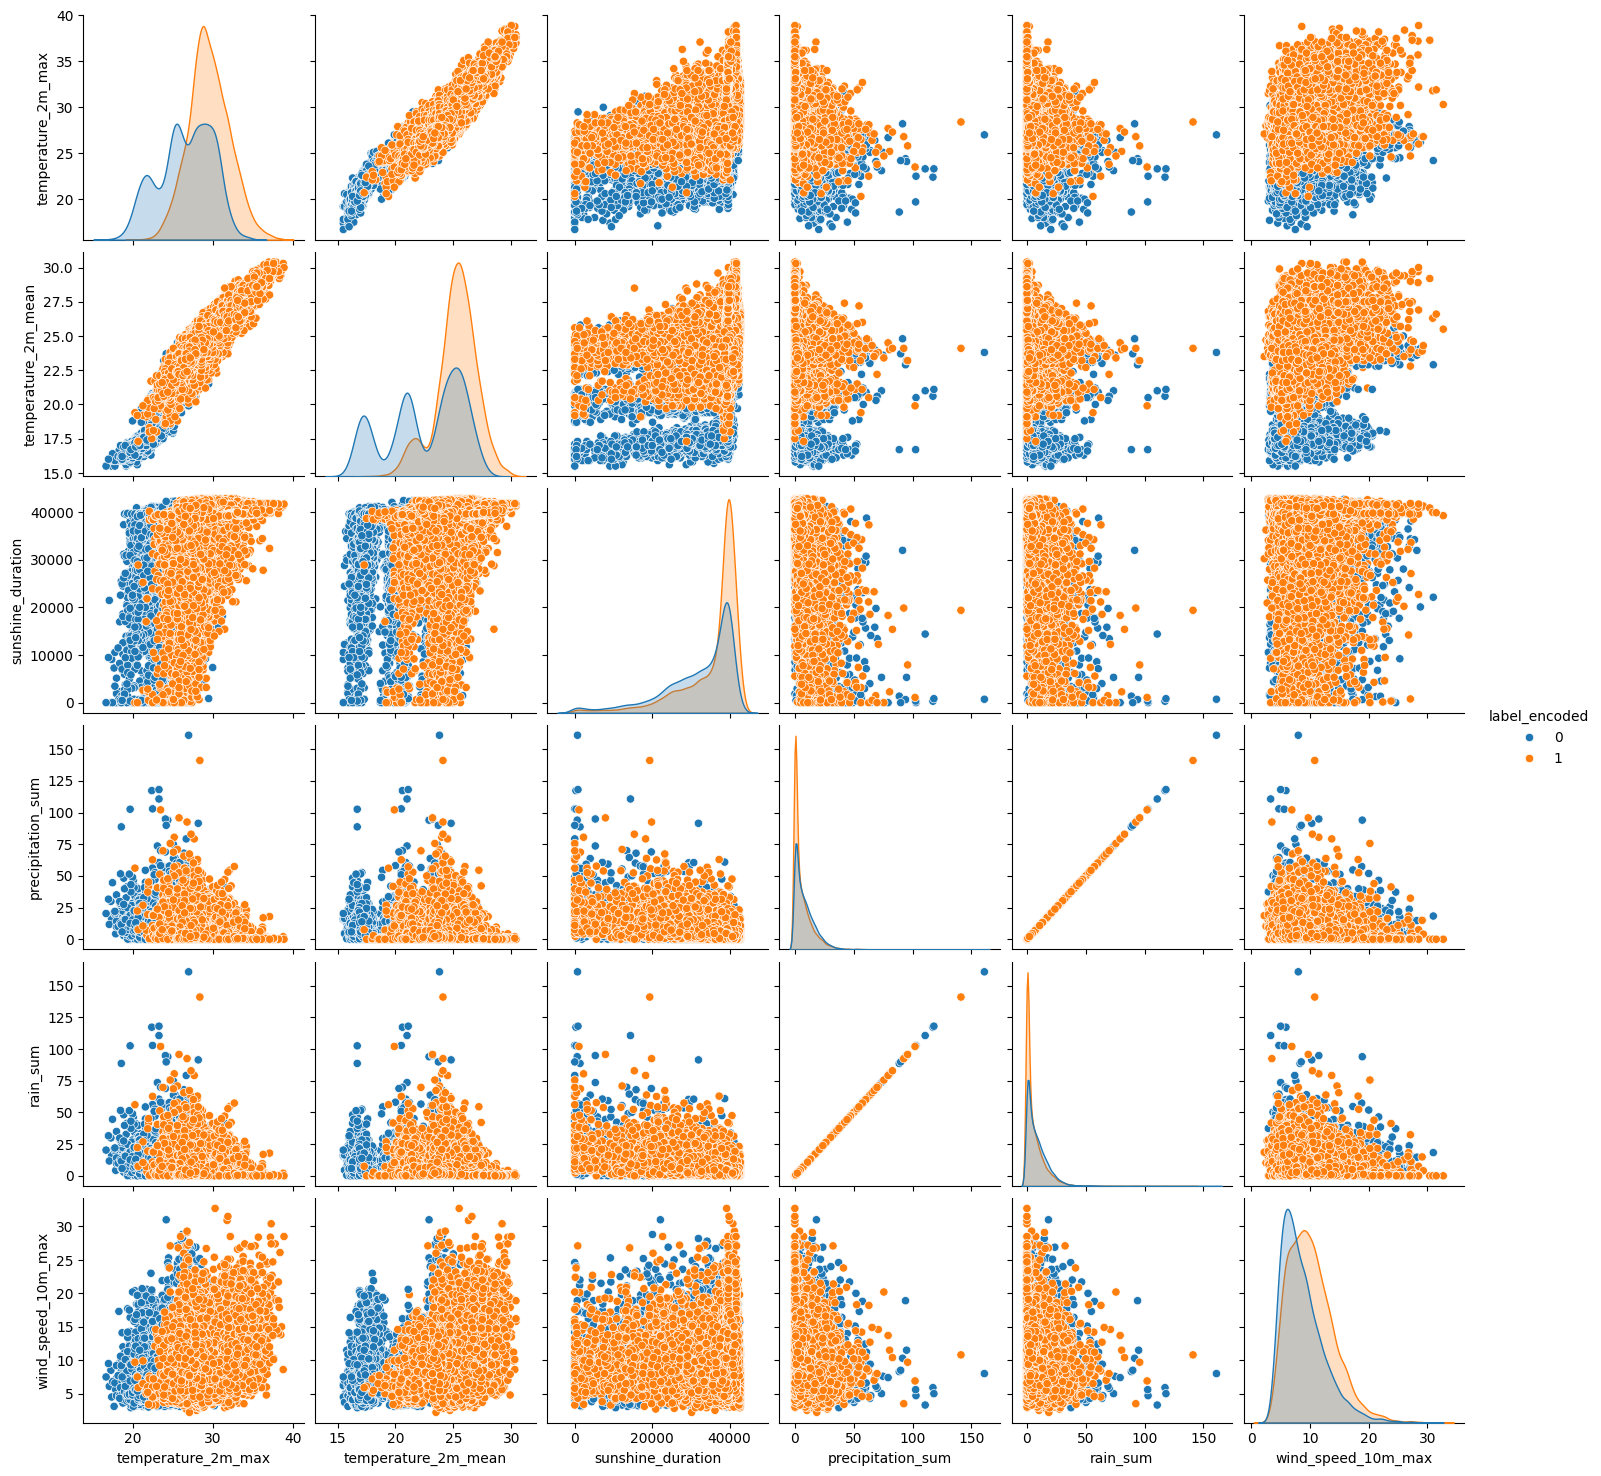

In [ ]:
sns.pairplot(df[features + ['label_encoded']], hue='label_encoded')
plt.show()

# Model 1: LSTM

In [ ]:
print("\nTraining LSTM model...")
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train.values.reshape(-1, X_train.shape[1], 1), y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
loss, accuracy = lstm_model.evaluate(X_test.values.reshape(-1, X_test.shape[1], 1), y_test, verbose=0)
print(f"LSTM Model - Test Accuracy: {accuracy:.4f}")



Training LSTM model...
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


427/427 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5872 - loss: 0.6605 - val_accuracy: 0.7014 - val_loss: 0.5781
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6992 - loss: 0.5762 - val_accuracy: 0.6982 - val_loss: 0.5817
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6928 - loss: 0.5783 - val_accuracy: 0.7052 - val_loss: 0.5726
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6973 - loss: 0.5701 - val_accuracy: 0.7008 - val_loss: 0.5820
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7019 - loss: 0.5643 - val_accuracy: 0.6996 - val_loss: 0.5734
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7051 - loss: 0.5618 - val_accuracy: 0.7031 - val_loss: 0.5707
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7005 - loss: 0.5664 - val_accuracy: 0.7072 - val_loss: 0.5673
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7086 - loss: 0.5621 - val_accuracy: 0.7064 - val

#Model 2: GRU

In [ ]:
print("\nTraining GRU model...")
gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.fit(X_train.values.reshape(-1, X_train.shape[1], 1), y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
loss, accuracy = gru_model.evaluate(X_test.values.reshape(-1, X_test.shape[1], 1), y_test, verbose=0)
print(f"GRU Model - Test Accuracy: {accuracy:.4f}")


Training GRU model...
Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5945 - loss: 0.6590 - val_accuracy: 0.5990 - val_loss: 0.6663
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6724 - loss: 0.6022 - val_accuracy: 0.7008 - val_loss: 0.5831
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6972 - loss: 0.5713 - val_accuracy: 0.7040 - val_loss: 0.5747
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7048 - loss: 0.5651 - val_accuracy: 0.7084 - val_loss: 0.5698
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7010 - loss: 0.5684 - val_accuracy: 0.7046 - val_loss: 0.5708
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7026 - loss: 0.5640 - val_accuracy: 0.7026 - val_loss: 0.5741
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6937 - loss: 0.5711 - val_accuracy: 0.7093 - val_loss: 0.5668
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7067 - loss: 0

#Model 3: RNN

In [ ]:
print("\nTraining RNN model...")
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.fit(X_train.values.reshape(-1, X_train.shape[1], 1), y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
loss, accuracy = rnn_model.evaluate(X_test.values.reshape(-1, X_test.shape[1], 1), y_test, verbose=0)
print(f"RNN Model - Test Accuracy: {accuracy:.4f}")


Training RNN model...
Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6306 - loss: 0.6307 - val_accuracy: 0.6970 - val_loss: 0.5719
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6962 - loss: 0.5715 - val_accuracy: 0.6993 - val_loss: 0.5727
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7008 - loss: 0.5679 - val_accuracy: 0.7061 - val_loss: 0.5624
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7130 - loss: 0.5508 - val_accuracy: 0.7075 - val_loss: 0.5515
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7115 - loss: 0.5486 - val_accuracy: 0.7119 - val_loss: 0.5499
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7082 - loss: 0.5519 - val_accuracy: 0.7122 - val_loss: 0.5590
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7128 - loss: 0.5454 - val_accuracy: 0.7111 - val_loss: 0.5414
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7152 - loss: 0.

#Model 4: CNN

In [ ]:
print("\nTraining CNN model...")
cnn_model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train.values.reshape(-1, X_train.shape[1], 1), y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
loss, accuracy = cnn_model.evaluate(X_test.values.reshape(-1, X_test.shape[1], 1), y_test, verbose=0)
print(f"CNN Model - Test Accuracy: {accuracy:.4f}")


Training CNN model...
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


427/427 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6160 - loss: 0.6454 - val_accuracy: 0.6882 - val_loss: 0.5791
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6989 - loss: 0.5721 - val_accuracy: 0.7070 - val_loss: 0.5763
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7094 - loss: 0.5612 - val_accuracy: 0.7055 - val_loss: 0.5625
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6956 - loss: 0.5707 - val_accuracy: 0.7096 - val_loss: 0.5638
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7156 - loss: 0.5510 - val_accuracy: 0.6935 - val_loss: 0.5820
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7057 - loss: 0.5542 - val_accuracy: 0.7058 - val_loss: 0.5608
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7084 - loss: 0.5579 - val_accuracy: 0.7087 - val_loss: 0.5581
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7029 - loss: 0.5592 - val_accuracy: 0.7058 - val_